In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
import tensorflow as tf

c:\Users\Kim_W\BI_Assignment\BI_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

# Predicting weather a flight will arrive more than 15 minutes late

In [4]:
data_2003 = pd.read_csv('data_2003_2.csv', low_memory = False)
data_2003

,Unnamed: 0,CRSElapsedTime,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,time_of_day_CRSDepTime,time_of_day_CRSArrTime,Weekend,Season,Delay
0,0,138.0,29.0,ORD,MSY,837,5,17,3,4,0,1,1
1,1,239.0,-4.0,OAK,ORD,1835,13,13,2,3,0,1,0
2,2,239.0,0.0,OAK,ORD,1835,5,9,2,3,1,1,0
3,3,239.0,-4.0,OAK,ORD,1835,7,14,2,3,0,1,1
4,4,97.0,3.0,IAD,BOS,413,7,29,3,4,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1839026,1839026,98.0,37.0,SRQ,ATL,445,11,12,2,2,0,1,1
1839027,1839027,219.0,26.0,LAS,CVG,1678,7,17,3,4,0,1,1
1839028,1839028,131.0,44.0,AUS,ATL,813,10,18,2,2,0,1,1
1839029,1839029,96.0,50.0,ATL,IND,432,8,21,4,4,0,1,1


In [5]:
data_2003 = data_2003.drop(['Unnamed: 0'], axis=1)

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

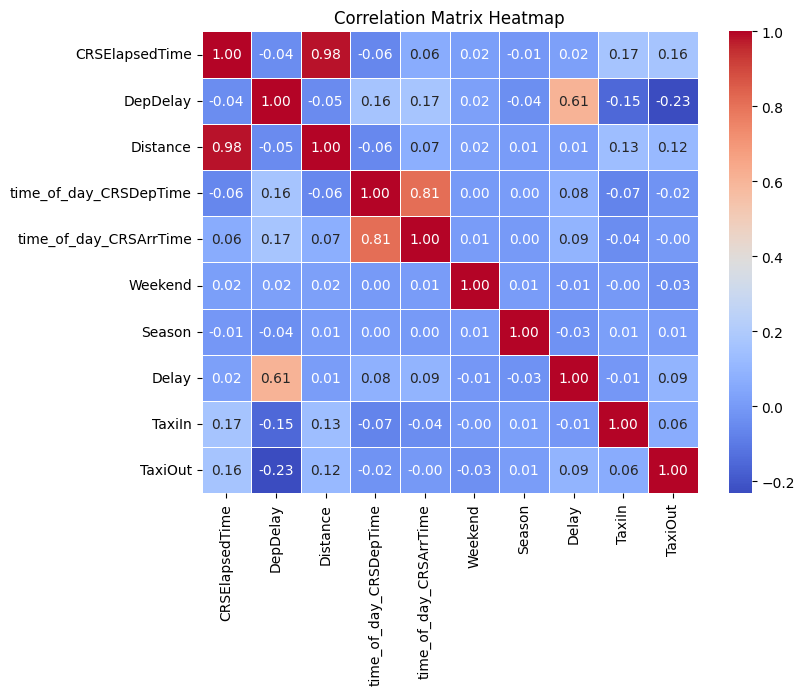

In [6]:
plt.figure(figsize=(8, 6))
corr = data_2003[['CRSElapsedTime',	'DepDelay',	'Distance',	'time_of_day_CRSDepTime',	'time_of_day_CRSArrTime',	'Weekend',	'Season',	'Delay', 'TaxiIn', 'TaxiOut']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')

## 1. Training, Test & Validation Set

In [7]:
X_2003 = data_2003.drop(columns = ['Delay', 'CRSElapsedTime', 'Distance', 'Weekend', 'Season', 'TaxiIn'], axis=1)
y_2003 = data_2003['Delay']

In [9]:
categorical_cols_2003 = X_2003.select_dtypes(include='object').columns

numerical_cols_2003 = X_2003.select_dtypes(exclude='object').columns

In [10]:
X_2003_categorical_encoded = pd.get_dummies(X_2003[categorical_cols_2003], drop_first=True, dummy_na=False)

X_2003_processed = pd.concat([X_2003[numerical_cols_2003], X_2003_categorical_encoded], axis=1)

In [11]:
Scaler_2003 = StandardScaler()
X_2003_scaled = Scaler_2003.fit_transform(X_2003_processed)

In [12]:
X_train_2003, X_temp_2003, y_train_2003, y_temp_2003 = train_test_split(X_2003_scaled, y_2003, test_size=0.30, random_state=42, stratify=y_2003)
X_val_2003, X_test_2003, y_val_2003, y_test_2003 = train_test_split(X_temp_2003, y_temp_2003, test_size=0.50, random_state=42, stratify=y_temp_2003)

In [13]:
print("Data_2003 preparation and splitting complete.")
print(f"X_train_2003 shape: {X_train_2003.shape}")
print(f"X_val_2003 shape: {X_val_2003.shape}")
print(f"X_test_2003 shape: {X_test_2003.shape}")
print(f"y_train_2003 shape: {y_train_2003.shape}")
print(f"y_val_2003 shape: {y_val_2003.shape}")
print(f"y_test_2003 shape: {y_test_2003.shape}")

Data_2003 preparation and splitting complete.
X_train_2003 shape: (1287321, 556)
X_val_2003 shape: (275855, 556)
X_test_2003 shape: (275855, 556)
y_train_2003 shape: (1287321,)
y_val_2003 shape: (275855,)
y_test_2003 shape: (275855,)


## 2. Model Generation

In [14]:
def create_nn_model(input_shape):
    
    Dense = tf.keras.layers.Dense
           
    model = tf.keras.Sequential()
    model.add(keras.layers.Input(shape=(input_shape,)))
    model.add(Dense(units=64, activation='relu'))
    model.add(Dense(units=32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [15]:
input_shape_2003 = X_train_2003.shape[1]

## 3. Fitting Model

In [16]:
early_stopping = EarlyStopping(monitor='val_loss', patience= 5, restore_best_weights = True)

In [17]:
#model_2003 = tuner.hypermodel.build(best_hp)
model_2003 = create_nn_model(input_shape_2003)
model_2003.fit(X_train_2003, y_train_2003, epochs=10, batch_size=32, validation_data=(X_val_2003, y_val_2003), callbacks=[early_stopping])

Epoch 1/10
40229/40229 ━━━━━━━━━━━━━━━━━━━━ 74s 2ms/step - accuracy: 0.8540 - loss: 0.3562 - val_accuracy: 0.8593 - val_loss: 0.3441
Epoch 2/10
40229/40229 ━━━━━━━━━━━━━━━━━━━━ 75s 2ms/step - accuracy: 0.8598 - loss: 0.3419 - val_accuracy: 0.8603 - val_loss: 0.3405
Epoch 3/10
40229/40229 ━━━━━━━━━━━━━━━━━━━━ 69s 2ms/step - accuracy: 0.8608 - loss: 0.3392 - val_accuracy: 0.8615 - val_loss: 0.3395
Epoch 4/10
40229/40229 ━━━━━━━━━━━━━━━━━━━━ 72s 2ms/step - accuracy: 0.8616 - loss: 0.3377 - val_accuracy: 0.8601 - val_loss: 0.3406
Epoch 5/10
40229/40229 ━━━━━━━━━━━━━━━━━━━━ 77s 2ms/step - accuracy: 0.8618 - loss: 0.3368 - val_accuracy: 0.8621 - val_loss: 0.3365
Epoch 6/10
40229/40229 ━━━━━━━━━━━━━━━━━━━━ 74s 2ms/step - accuracy: 0.8622 - loss: 0.3360 - val_accuracy: 0.8623 - val_loss: 0.3357
Epoch 7/10
40229/40229 ━━━━━━━━━━━━━━━━━━━━ 70s 2ms/step - accuracy: 0.8624 - loss: 0.3355 - val_accuracy: 0.8609 - val_loss: 0.3400
Epoch 8/10
40229/40229 ━━━━━━━━━━━━━━━━━━━━ 70s 2ms/step - accuracy: 

## 4. Model Evaluation

In [18]:
loss_2003, accuracy_2003 = model_2003.evaluate(X_test_2003, y_test_2003)
print(f"Test Loss for 2003 model: {loss_2003:.4f}")
print(f"Test Accuracy for 2003 model: {accuracy_2003:.4f}")

8621/8621 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.8633 - loss: 0.3338
Test Loss for 2003 model: 0.3338
Test Accuracy for 2003 model: 0.8633


8621/8621 ━━━━━━━━━━━━━━━━━━━━ 5s 611us/step


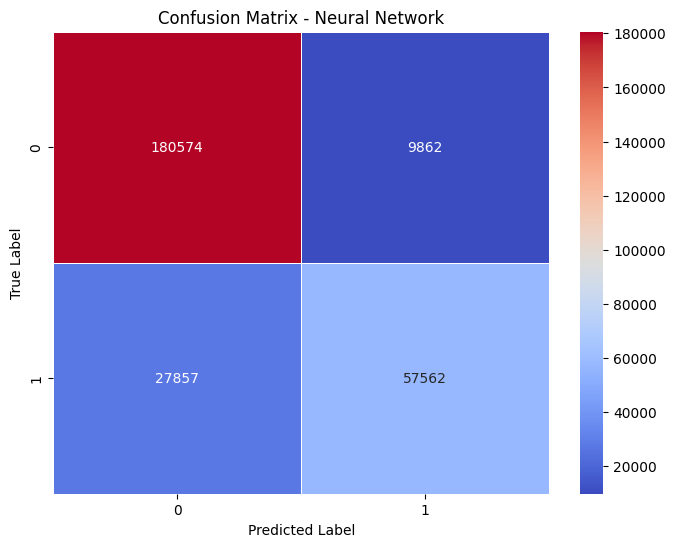

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix
y_pred_probs = model_2003.predict(X_test_2003)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test_2003, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d', linewidths=0.5)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Neural Network")
plt.show()

In [20]:
model_2003.save("2003_model_base.h5")